# <font size = "5"> Import Packages and Dataset

In [51]:
# The "pandas" library is used for processing datasets
# The "numpy" is for numeric observations and random numbers
# The "matplotlib.pyplot" library is for creating graphs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We will use the "sklearn" package

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn import tree
import sklearn.model_selection as skm
from sklearn.ensemble import RandomForestRegressor as RF
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.model_selection import (cross_validate, KFold, ShuffleSplit)
from sklearn import preprocessing
from sklearn.metrics import get_scorer_names
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# This is used to create data matrices
import patsy

# This is used to visualize regreesion trees
import graphviz

# Import content from the book "Introduction to Statistical Learning"
import ISLP

# Import the package for the University of California Irvine API
from ucimlrepo import fetch_ucirepo 

In [73]:
# Import dataset
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
# metadata 
print(iris.metadata) 
  
# variable information 
print(iris.variables) 


{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

# <font size = "5">

Data Description

In [74]:
print(X.head()) #First few rows of X 
print("Shape of X:", X.shape) # shape of X
print("Shape of y:", y.shape) # shape of y

   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
Shape of X: (150, 4)
Shape of y: (150, 1)


X has 150 rows, 4 columns. y has 150 rows, 1 column

In [75]:
print(y["class"].value_counts(normalize=True)) # proportion of y

class
Iris-setosa        0.333333
Iris-versicolor    0.333333
Iris-virginica     0.333333
Name: proportion, dtype: float64


In [76]:
display(X.describe())

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# <span style="color:darkblue"> Machine Learning

In [77]:
# Split data: 70% training, 30% test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y['class'], test_size=0.3, random_state=123, stratify=y
)

# <font size = "5"> Logistic Regression

In [41]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Test accuracy: 0.9777777777777777


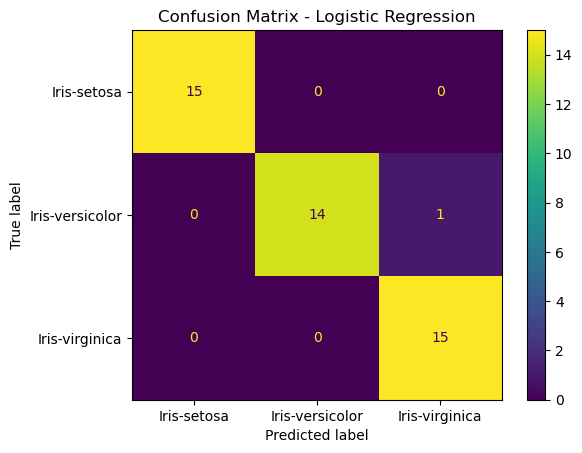

In [ ]:
# Accuracy and ConfusionMatrix
test_score = log_model.score(X_test, y_test)
print("Test accuracy:", test_score)

ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
# Cross-validated error rate
scores = cross_val_score(log_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - scores.mean())

Cross-validated error rate: 0.026666666666666616


# <font size = "5"> Decision Tree

In [46]:
tree_model = DecisionTreeClassifier(max_depth=3,random_state = 123) 
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=123)

In [48]:
# Cross-validated error rate
tree_scores = cross_val_score(tree_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - tree_scores.mean())

Cross-validated error rate: 0.040000000000000036


0.9111111111111111


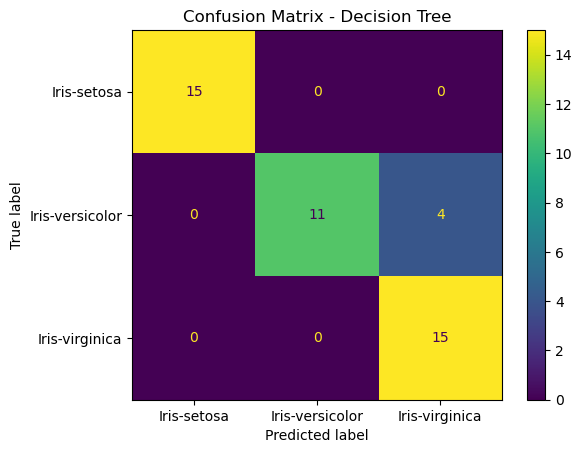

In [ ]:
# Accuracy and ConfusionMatrix
y_pred = tree_model.predict(X_test) 
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# <font size = "5"> Random Forest - default

In [56]:
rf_model = RandomForestClassifier(random_state=123)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

0.9555555555555556


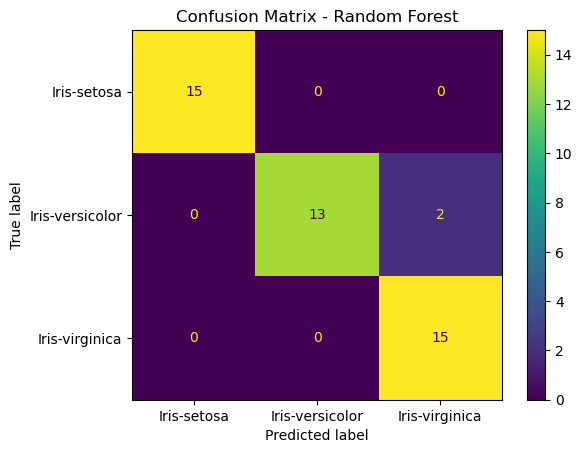

In [ ]:
# Accuracy and ConfusionMatrix
y_pred = rf_model.predict(X_test) 
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [58]:
# Cross-validated error rate
rf_scores = cross_val_score(rf_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - rf_scores.mean())

Cross-validated error rate: 0.040000000000000036


# <font size = "5">  Random Forest - tuning grid

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
rf_model = RandomForestClassifier(random_state=123)

In [91]:
param_grid = {
    'n_estimators':     [50, 100, 200],   # number of trees
    'max_depth':        [None, 3, 5, 8], # tree depth
    'min_samples_split':[2, 4, 8],       # minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]        # minimum samples in a leaf
}
# Grid search with 5-fold CV 
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1          # use all CPU cores if available
)

grid_search.fit(X_train, y_train)

print("Best parameters from grid search:")
print(grid_search.best_params_)
print("Best mean CV accuracy on training folds:",
      grid_search.best_score_)

Best parameters from grid search:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best mean CV accuracy on training folds: 0.9619047619047618


0.9555555555555556


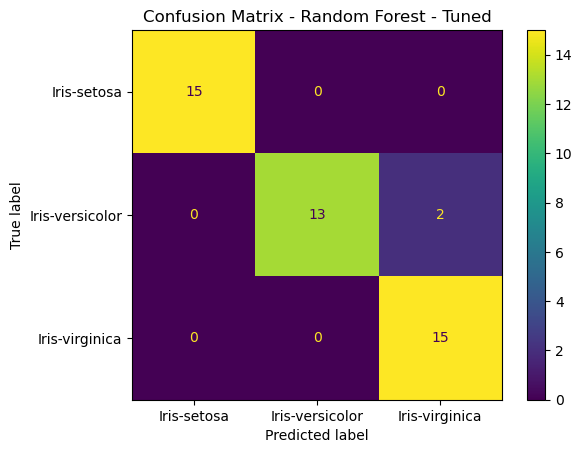

In [92]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Random Forest - Tuned")
plt.show()

# <font size = "5"> Support Vector Machines 

In [61]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

0.9555555555555556


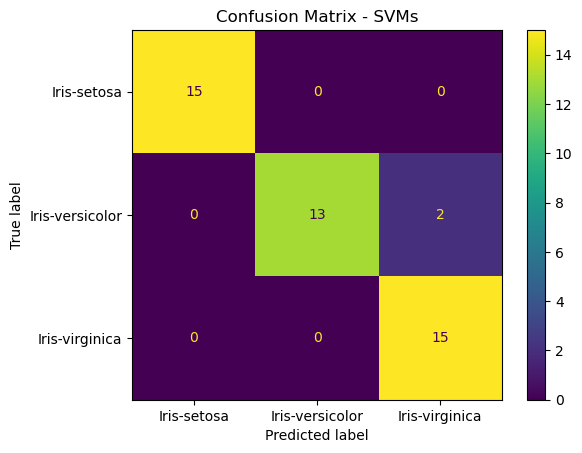

In [62]:
# Accuracy and ConfusionMatrix
y_pred = svm_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - SVMs")
plt.show()

In [63]:
# Cross-validated error rate
svm_scores = cross_val_score(svm_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - svm_scores.mean())

Cross-validated error rate: 0.03333333333333344


# <font size = "5"> Neural Network

In [78]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score

In [ ]:
nn_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=1000, random_state=42)
)

# Fit model on training data
nn_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(max_iter=1000, random_state=42))])

0.9333333333333333


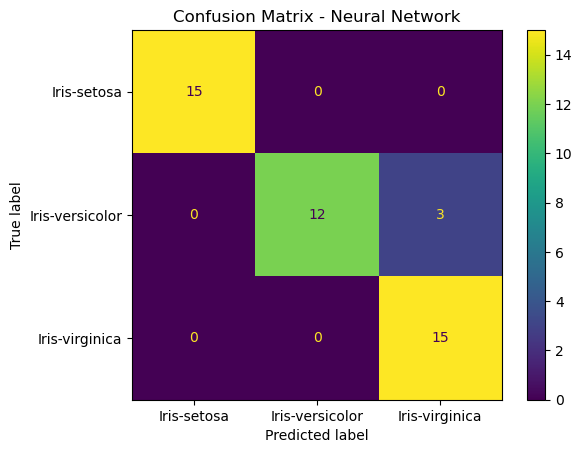

In [ ]:
# Accuracy and ConfusionMatrix
y_pred = nn_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [86]:
# Cross-validated error rate
nn_scores = cross_val_score(nn_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - nn_scores.mean())

Cross-validated error rate: 0.039999999999999813


# <font size = "5"> LASSO

In [87]:
lasso_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l1',          # LASSO regularization
        solver='liblinear',    # required solver for L1
        max_iter=1000,
        random_state=42
    )
)
lasso_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

0.9555555555555556


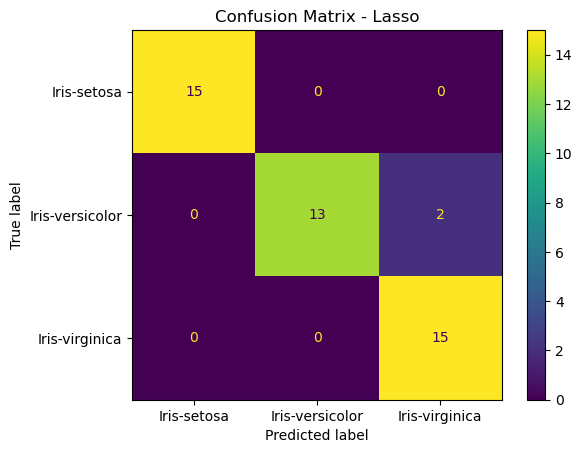

In [ ]:
# Accuracy and ConfusionMatrix
y_pred = lasso_model.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Lasso")
plt.show()

In [89]:
# Cross-validated error rate
lasso_scores = cross_val_score(lasso_model, X, y['class'], cv=5, scoring='accuracy')
print("Cross-validated error rate:", 1 - lasso_scores.mean())

Cross-validated error rate: 0.06666666666666676


To sum up, Among all the methods, logistic regression has the best accuracy and the smallest cross-validated error. So I think it is the best way to predict data.